# Binary Classification Metrics

Accuracy alone can be misleading — especially on imbalanced data. This notebook covers the fuller toolkit for evaluating a binary classifier: the confusion matrix, precision, recall, F1, and ROC/AUC — built from scratch first, then compared against sklearn's functions.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

## 1. Load the Data

The breast cancer dataset: predict whether a tumor is malignant (0) or benign (1) from 30 numeric features. Genuinely binary, and a classic case where **accuracy alone isn't enough** — missing a malignant tumor (a false negative) is far worse than a false alarm.

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print(data.target_names)   # ['malignant' 'benign']
X.head()

['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
y.value_counts()

1    357
0    212
Name: count, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
X_train.shape, X_test.shape

((455, 30), (114, 30))

## 2. Fit a Model

Logistic Regression as the baseline classifier for this notebook.

In [5]:
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

## 3. Confusion Matrix

The confusion matrix breaks predictions into four buckets. Rows are actual class, columns are predicted class:

```
[[TN  FP]
 [FN  TP]]
```

- **TP** (True Positive): predicted 1, actually 1
- **TN** (True Negative): predicted 0, actually 0
- **FP** (False Positive): predicted 1, actually 0 — a "false alarm"
- **FN** (False Negative): predicted 0, actually 1 — a "miss" 

In [6]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[41  4]
 [ 4 65]]


In [7]:
# Derive TP/TN/FP/FN manually to see exactly what the matrix means
TP = sum(1 for actual, pred in zip(y_test, y_pred) if actual == 1 and pred == 1)
TN = sum(1 for actual, pred in zip(y_test, y_pred) if actual == 0 and pred == 0)
FP = sum(1 for actual, pred in zip(y_test, y_pred) if actual == 0 and pred == 1)
FN = sum(1 for actual, pred in zip(y_test, y_pred) if actual == 1 and pred == 0)

print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")

TP=65  TN=41  FP=4  FN=4


## 4. Accuracy

The simplest metric — fraction of all predictions that were correct. Breaks down on imbalanced data: a model that always predicts the majority class can still score high accuracy while being useless.

In [8]:
accuracy_manual = (TP + TN) / (TP + TN + FP + FN)
print(f"Manual:  {accuracy_manual:.4f}")
print(f"sklearn: {accuracy_score(y_test, y_pred):.4f}")

Manual:  0.9298
sklearn: 0.9298


## 5. Precision

**Precision** answers: *of everything predicted positive, how much was actually positive?*

$$Precision = \frac{TP}{TP + FP}$$

High precision means few false alarms. Matters most when false positives are costly (e.g. flagging a healthy patient as sick and putting them through unnecessary treatment).

In [9]:
precision_manual = TP / (TP + FP)
print(f"Manual:  {precision_manual:.4f}")
print(f"sklearn: {precision_score(y_test, y_pred):.4f}")

Manual:  0.9420
sklearn: 0.9420


## 6. Recall

**Recall** (also called sensitivity or true positive rate) answers: *of everything that was actually positive, how much did we catch?*

$$Recall = \frac{TP}{TP + FN}$$

High recall means few misses. Matters most when false negatives are costly (e.g. missing an actual malignant tumor) — often the priority in medical screening.

In [10]:
recall_manual = TP / (TP + FN)
print(f"Manual:  {recall_manual:.4f}")
print(f"sklearn: {recall_score(y_test, y_pred):.4f}")

Manual:  0.9420
sklearn: 0.9420


## 7. F1 Score

Precision and recall trade off against each other — improving one often hurts the other. **F1** is their harmonic mean, giving one number that balances both:

$$F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}$$

Useful when you care about both false positives and false negatives, and want a single number to compare models.

In [11]:
f1_manual = (2 * precision_manual * recall_manual) / (precision_manual + recall_manual)
print(f"Manual:  {f1_manual:.4f}")
print(f"sklearn: {f1_score(y_test, y_pred):.4f}")

Manual:  0.9420
sklearn: 0.9420


**Why harmonic mean, not a plain average?** It punishes a big imbalance between precision and recall much more than a normal average would. A model with precision=1.0 and recall=0.1 has a normal average of 0.55, but its F1 is only ~0.18 — reflecting that the model is actually bad despite one metric looking perfect.

## 8. The Rest of the Confusion Matrix Metric Family

Precision and recall are the two most commonly used, but TP/TN/FP/FN can be combined in several other ways depending on what question matters for the problem. sklearn doesn't have dedicated functions for most of these, so they're computed directly from the confusion matrix counts.

| Metric | Formula | Question it answers |
|---|---|---|
| **TPR** (Recall / Sensitivity) | `TP/(TP+FN)` | Of actual positives, how many did we catch? |
| **TNR** (Specificity) | `TN/(TN+FP)` | Of actual negatives, how many did we correctly rule out? |
| **PPV** (Precision) | `TP/(TP+FP)` | Of predicted positives, how many were right? |
| **NPV** | `TN/(TN+FN)` | Of predicted negatives, how many were right? |
| **FNR** (Miss Rate) | `FN/(TP+FN)` | Of actual positives, how many did we miss? (`1 - TPR`) |
| **FPR** (Fall-out) | `FP/(FP+TN)` | Of actual negatives, how many did we wrongly flag? (`1 - TNR`) |
| **FDR** | `FP/(TP+FP)` | Of predicted positives, how many were actually wrong? (`1 - PPV`) |
| **FOR** | `FN/(TN+FN)` | Of predicted negatives, how many were actually wrong? (`1 - NPV`) |

In [12]:
TPR = TP / (TP + FN)   # Recall / Sensitivity — same as recall_score above
TNR = TN / (TN + FP)   # Specificity
PPV = TP / (TP + FP)   # Precision — same as precision_score above
NPV = TN / (TN + FN)

FNR = FN / (TP + FN)   # Miss rate
FPR = FP / (FP + TN)   # Fall-out
FDR = FP / (TP + FP)   # False discovery rate
FOR = FN / (TN + FN)   # False omission rate

pd.DataFrame({
    'metric': ['TPR (Recall)', 'TNR (Specificity)', 'PPV (Precision)', 'NPV',
               'FNR', 'FPR', 'FDR', 'FOR'],
    'value': [TPR, TNR, PPV, NPV, FNR, FPR, FDR, FOR]
})

,metric,value
0,TPR (Recall),0.942029
1,TNR (Specificity),0.911111
2,PPV (Precision),0.942029
3,NPV,0.911111
4,FNR,0.057971
5,FPR,0.088889
6,FDR,0.057971
7,FOR,0.088889


**Specificity (TNR) is the one most worth knowing alongside precision/recall** — it's recall's mirror image for the negative class, and shows up constantly in medical and diagnostic contexts (e.g. "how good is this test at correctly clearing healthy patients?"). The rest are mostly each other's complements (`FNR = 1 - TPR`, `FPR = 1 - TNR`, etc.) — useful to recognize rather than memorize separately.

## 9. ROC Curve & ROC-AUC

Precision/recall/F1 all depend on a fixed decision threshold (default 0.5). The **ROC curve** shows how True Positive Rate (recall) and False Positive Rate trade off as that threshold changes — useful when you want to see a model's behavior across *all* thresholds, not just one.

- **ROC** = Receiver Operating Characteristic (the name is historical, from WW2 radar signal detection)
- **AUC** = Area Under the Curve — a single number summarizing the whole ROC curve. 1.0 is a perfect classifier, 0.5 is no better than random guessing (the diagonal line).

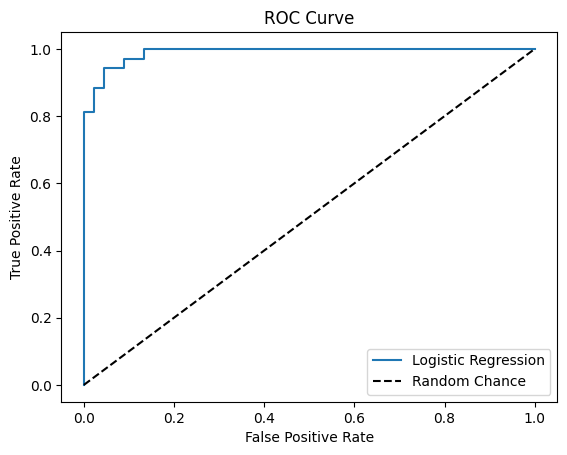

ROC-AUC Score: 0.9894


In [13]:
y_probs = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

### Comparing Models with ROC-AUC

ROC-AUC is especially useful for comparing different model types on the same footing, since it doesn't depend on picking one threshold.

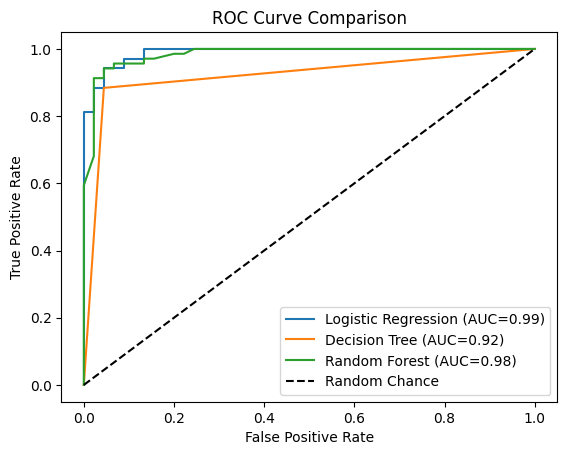

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=2),
    'Random Forest': RandomForestClassifier(random_state=2, n_jobs=-1),
}

plt.figure()
for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

---
## Binary Classification Metrics Cheat Sheet

### Confusion Matrix
| Code | Description |
|---|---|
| `confusion_matrix(y_test, y_pred)` | Returns `[[TN, FP], [FN, TP]]` |

### Core Metrics
| Metric | Formula | Question it answers |
|---|---|---|
| Accuracy | `(TP+TN)/(TP+TN+FP+FN)` | How much did we get right overall? |
| Precision (PPV) | `TP/(TP+FP)` | Of predicted positives, how many were right? |
| Recall (TPR) | `TP/(TP+FN)` | Of actual positives, how many did we catch? |
| F1 | `2*P*R/(P+R)` | Single balanced score of precision & recall |

### Extended Metric Family (no dedicated sklearn function — compute from the confusion matrix)
| Metric | Formula | Complement of |
|---|---|---|
| TNR (Specificity) | `TN/(TN+FP)` | — |
| NPV | `TN/(TN+FN)` | — |
| FNR (Miss Rate) | `FN/(TP+FN)` | `1 - TPR` |
| FPR (Fall-out) | `FP/(FP+TN)` | `1 - TNR` |
| FDR | `FP/(TP+FP)` | `1 - PPV` |
| FOR | `FN/(TN+FN)` | `1 - NPV` |

### Sklearn Functions
| Code | Description |
|---|---|
| `accuracy_score(y_test, y_pred)` | Accuracy |
| `precision_score(y_test, y_pred)` | Precision (PPV) |
| `recall_score(y_test, y_pred)` | Recall (TPR) |
| `f1_score(y_test, y_pred)` | F1 |
| `roc_curve(y_test, y_probs)` | Returns `fpr, tpr, thresholds` |
| `roc_auc_score(y_test, y_probs)` | Single AUC score |

### Gotchas
- Accuracy is misleading on imbalanced datasets — always check precision/recall too.
- Precision and recall trade off — optimizing one in isolation can silently hurt the other.
- sklearn only ships functions for accuracy/precision/recall/F1/ROC-AUC — TNR, NPV, FNR, FPR, FDR, FOR are computed directly from the confusion matrix counts.
- ROC/AUC needs **probabilities** (`predict_proba`), not class labels (`predict`).
- Which metric to prioritize depends on the cost of FP vs FN in your specific problem — there's no universally "best" metric.